# Setup and imports

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent

sys.path.insert(0, str(project_root))
print(f"Project root: {project_root.resolve()}")
print(f"Working dir:  {Path.cwd().resolve()}")

Project root: C:\Users\Axioo\Documents\Fahmi\ai\ml\predict-customer-churn
Working dir:  C:\Users\Axioo\Documents\Fahmi\ai\ml\predict-customer-churn\notebooks


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from src.data_loader import load_data
from src.config_loader import load_config

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

plt.rcParams['font.size'] = 10

# Load dataset

In [ ]:
config_path = project_root / "config" / "default.yaml"
config = load_config(str(config_path))
print(f"Experiment: {config['experiment']['name']}")
print(f"Seed: {config['experiment']['seed']}")
print()

train_path = Path(config['data']['train_path'])
test_path = Path(config['data']['test_path'])
target_col = config['data']['target_column']
id_col = config['data']['id_column']

if not train_path.is_absolute():
    train_path = project_root / train_path
if not test_path.is_absolute():
    test_path = project_root / test_path

print(f"Train path: {train_path.resolve()}")
print(f"Test path:  {test_path.resolve()}")

train_df = load_data(str(train_path))
test_df = load_data(str(test_path))

Experiment: default
Seed: 42

Train path: C:\Users\Axioo\Documents\Fahmi\ai\ml\predict-customer-churn\data\processed\train.parquet
Test path:  C:\Users\Axioo\Documents\Fahmi\ai\ml\predict-customer-churn\data\processed\test.parquet


# Overview

In [4]:
print(f"Shape: {train_df.shape[0]:,} rows x {train_df.shape[1]:,} columns")
print(f"Memory Usage: {train_df.memory_usage(deep=True).sum() / 1024 ** 2:.2f} MB")
display(train_df.head())

Shape: 594,194 rows x 21 columns
Memory Usage: 520.86 MB


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.100,1653.850,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.500,3778.200,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.400,5841.350,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.700,70.700,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.450,70.450,Yes


In [5]:
print(train_df.dtypes.value_counts())
print()

print("Column data types:")
display(pd.DataFrame({
    'Column': train_df.columns,
    'Type': train_df.dtypes.values,
    'Non-Null Count': train_df.count().values,
    'Null Count': train_df.isnull().sum().values,
    'Unique Values': [train_df[col].nunique() for col in train_df.columns]
}))

object     16
int64       3
float64     2
Name: count, dtype: int64

Column data types:


,Column,Type,Non-Null Count,Null Count,Unique Values
0,id,int64,594194,0,594194
1,gender,object,594194,0,2
2,SeniorCitizen,int64,594194,0,2
3,Partner,object,594194,0,2
4,Dependents,object,594194,0,2
5,tenure,int64,594194,0,72
6,PhoneService,object,594194,0,2
7,MultipleLines,object,594194,0,3
8,InternetService,object,594194,0,3
9,OnlineSecurity,object,594194,0,3


In [6]:
display(train_df.describe())

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000,594194.000,594194.000,594194.000,594194.000
mean,297096.500,0.114,36.577,65.866,2494.377
std,171529.177,0.318,25.062,31.067,2353.917
min,0.000,0.000,1.000,18.250,18.800
25%,148548.250,0.000,12.000,29.900,639.650
50%,297096.500,0.000,35.000,74.100,1433.650
75%,445644.750,0.000,62.000,90.800,4263.800
max,594193.000,1.000,72.000,118.750,8684.800


In [7]:
display(train_df.describe(include=['object', 'category']))

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Female,Yes,No,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,No
freq,298738,309554,414362,557893,283384,272386,289474,250083,247377,288571,240301,241435,298918,365579,215372,460377


# Missing values analysis

In [8]:
missing_data = pd.DataFrame({
    'Column': train_df.columns,
    'Missing_Count': train_df.isnull().sum().values,
    'Missing_Percentage': (train_df.isnull().sum() / len(train_df) * 100).values
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

if len(missing_data) > 0:
    display(missing_data)
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    missing_data.plot(x='Column', y='Missing_Percentage', kind='barh', ax=ax[0], color='coral')
    ax[0].set_xlabel('Missing Percentage (%)')
    ax[0].set_ylabel('Features')
    ax[0].set_title('Missing Values by Feature', fontsize=14, fontweight='bold')
    ax[0].grid(axis='x', alpha=0.3)
    
    missing_mask = train_df[missing_data['Column']].isnull()
    sns.heatmap(missing_mask.T, cbar=True, cmap='YlOrRd', ax=ax[1])
    ax[1].set_title('Missing Values Pattern (Yellow = Missing)', fontsize=14, fontweight='bold')
    ax[1].set_xlabel('Sample Index')
    
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset!")

No missing values found in the dataset!


# Numerical features analysis

In [9]:
numerical_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()

if id_col and id_col in numerical_cols:
    numerical_cols.remove(id_col)
if target_col in numerical_cols:
    numerical_cols.remove(target_col)
    
print(f"Found {len(numerical_cols)} numerical features: {numerical_cols}")

Found 4 numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


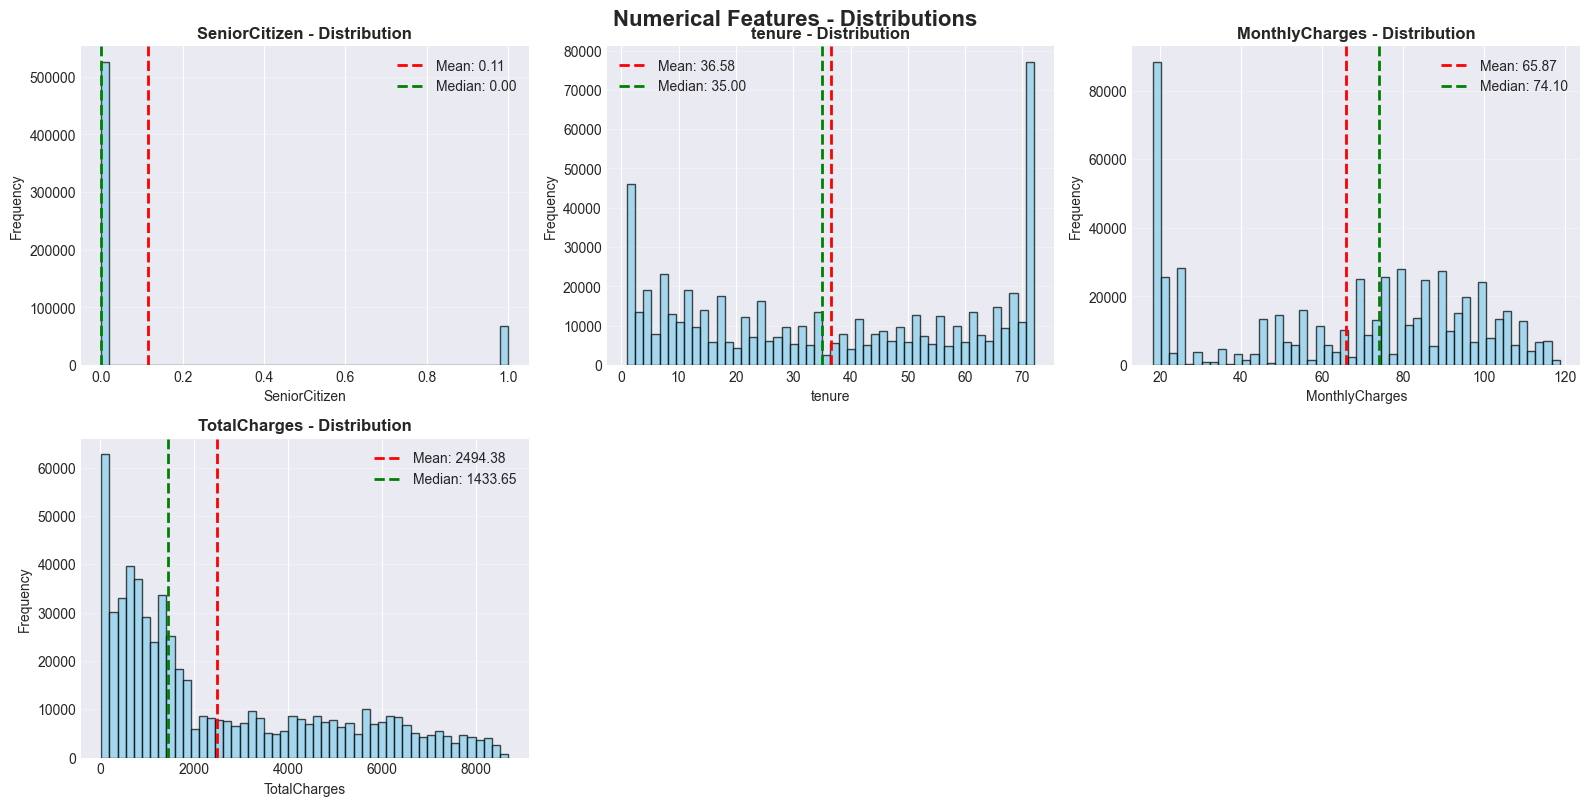

In [10]:
# Distribution plots for numerical features
if len(numerical_cols) > 0:
    n_cols = 3
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes
    
    for idx, col in enumerate(numerical_cols):
        ax = axes[idx]
        train_df[col].hist(bins=50, ax=ax, color='skyblue', edgecolor='black', alpha=0.7)
        ax.set_title(f'{col} - Distribution', fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Frequency')
        ax.grid(axis='y', alpha=0.3)
        
        mean_val = train_df[col].mean()
        median_val = train_df[col].median()
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
        ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
        ax.legend()
    
    for idx in range(len(numerical_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.suptitle('Numerical Features - Distributions', fontsize=16, fontweight='bold', y=1.002)
    plt.show()

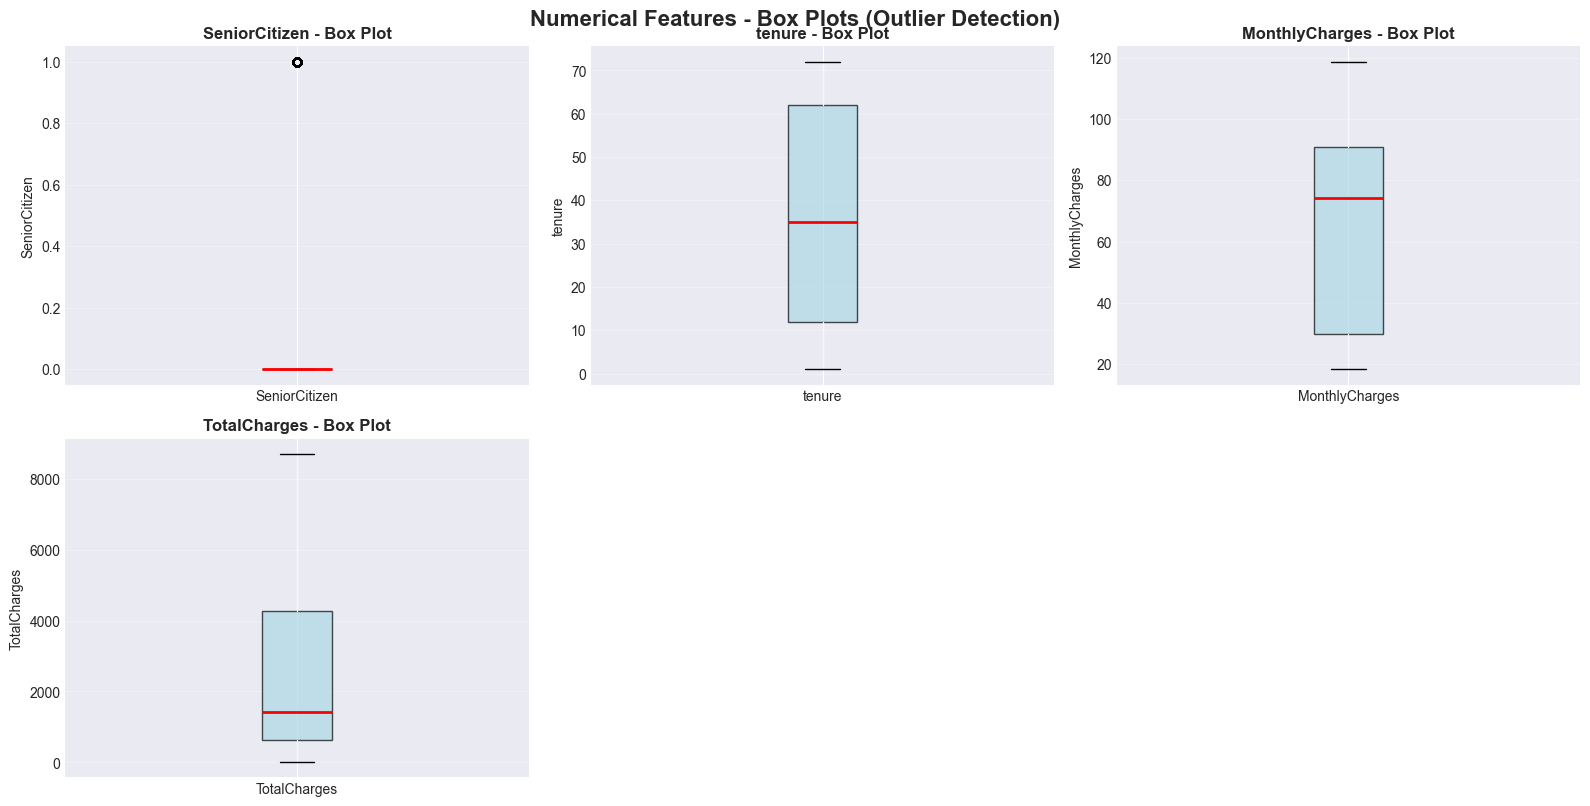

In [11]:
# Box plots for outlier detection
if len(numerical_cols) > 0:
    n_cols = 3
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes
    
    for idx, col in enumerate(numerical_cols):
        ax = axes[idx]
        train_df.boxplot(column=col, ax=ax, patch_artist=True,
                        boxprops=dict(facecolor='lightblue', alpha=0.7),
                        medianprops=dict(color='red', linewidth=2))
        ax.set_title(f'{col} - Box Plot', fontweight='bold')
        ax.set_ylabel(col)
        ax.grid(axis='y', alpha=0.3)
    
    for idx in range(len(numerical_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.suptitle('Numerical Features - Box Plots (Outlier Detection)', fontsize=16, fontweight='bold', y=1.002)
    plt.show()

In [12]:
# Statistical summary with skewness and kurtosis
if len(numerical_cols) > 0:
    stats_summary = pd.DataFrame({
        'Feature': numerical_cols,
        'Mean': [train_df[col].mean() for col in numerical_cols],
        'Median': [train_df[col].median() for col in numerical_cols],
        'Std': [train_df[col].std() for col in numerical_cols],
        'Min': [train_df[col].min() for col in numerical_cols],
        'Max': [train_df[col].max() for col in numerical_cols],
        'Skewness': [train_df[col].skew() for col in numerical_cols],
        'Kurtosis': [train_df[col].kurtosis() for col in numerical_cols],
        'Outliers (IQR)': [
            len(train_df[(train_df[col] < (train_df[col].quantile(0.25) - 1.5 * (train_df[col].quantile(0.75) - train_df[col].quantile(0.25)))) | 
                         (train_df[col] > (train_df[col].quantile(0.75) + 1.5 * (train_df[col].quantile(0.75) - train_df[col].quantile(0.25))))])
            for col in numerical_cols
        ]
    })
    
    display(stats_summary.style.background_gradient(cmap='coolwarm', subset=['Skewness', 'Kurtosis']))

,Feature,Mean,Median,Std,Min,Max,Skewness,Kurtosis,Outliers (IQR)
0,SeniorCitizen,0.114102,0.000000,0.317936,0.000000,1.000000,2.427526,3.892894,67799
1,tenure,36.577258,35.000000,25.061922,1.000000,72.000000,0.063050,-1.487182,0
2,MonthlyCharges,65.866223,74.100000,31.067444,18.250000,118.750000,-0.289486,-1.277955,0
3,TotalCharges,2494.377057,1433.650000,2353.916710,18.800000,8684.800000,0.909169,-0.446287,0


# Categorical features analysis

In [13]:
categorical_cols = train_df.select_dtypes(include=['object', 'category']).columns.tolist()

if id_col and id_col in categorical_cols:
    categorical_cols.remove(id_col)

print(f"Found {len(categorical_cols)} categorical features: {categorical_cols}")

Found 16 categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [14]:
# Value counts for categorical features
if len(categorical_cols) > 0:
    for col in categorical_cols:
        value_counts = train_df[col].value_counts()
        print(f"Unique values: {train_df[col].nunique()}")
        print(f"Most common: {value_counts.index[0]} ({value_counts.iloc[0]} occurrences)")
        print()
        print("Top 10 values:")
        display(pd.DataFrame({
            'Value': value_counts.head(10).index,
            'Count': value_counts.head(10).values,
            'Percentage': (value_counts.head(10) / len(train_df) * 100).values
        }))
        print()

Unique values: 2
Most common: Female (298738 occurrences)

Top 10 values:


,Value,Count,Percentage
0,Female,298738,50.276
1,Male,295456,49.724



Unique values: 2
Most common: Yes (309554 occurrences)

Top 10 values:


,Value,Count,Percentage
0,Yes,309554,52.096
1,No,284640,47.904



Unique values: 2
Most common: No (414362 occurrences)

Top 10 values:


...

,Value,Count,Percentage
0,Yes,365579,61.525
1,No,228615,38.475



Unique values: 4
Most common: Electronic check (215372 occurrences)

Top 10 values:


,Value,Count,Percentage
0,Electronic check,215372,36.246
1,Credit card (automatic),133705,22.502
2,Mailed check,123757,20.828
3,Bank transfer (automatic),121360,20.424



Unique values: 2
Most common: No (460377 occurrences)

Top 10 values:


,Value,Count,Percentage
0,No,460377,77.479
1,Yes,133817,22.521


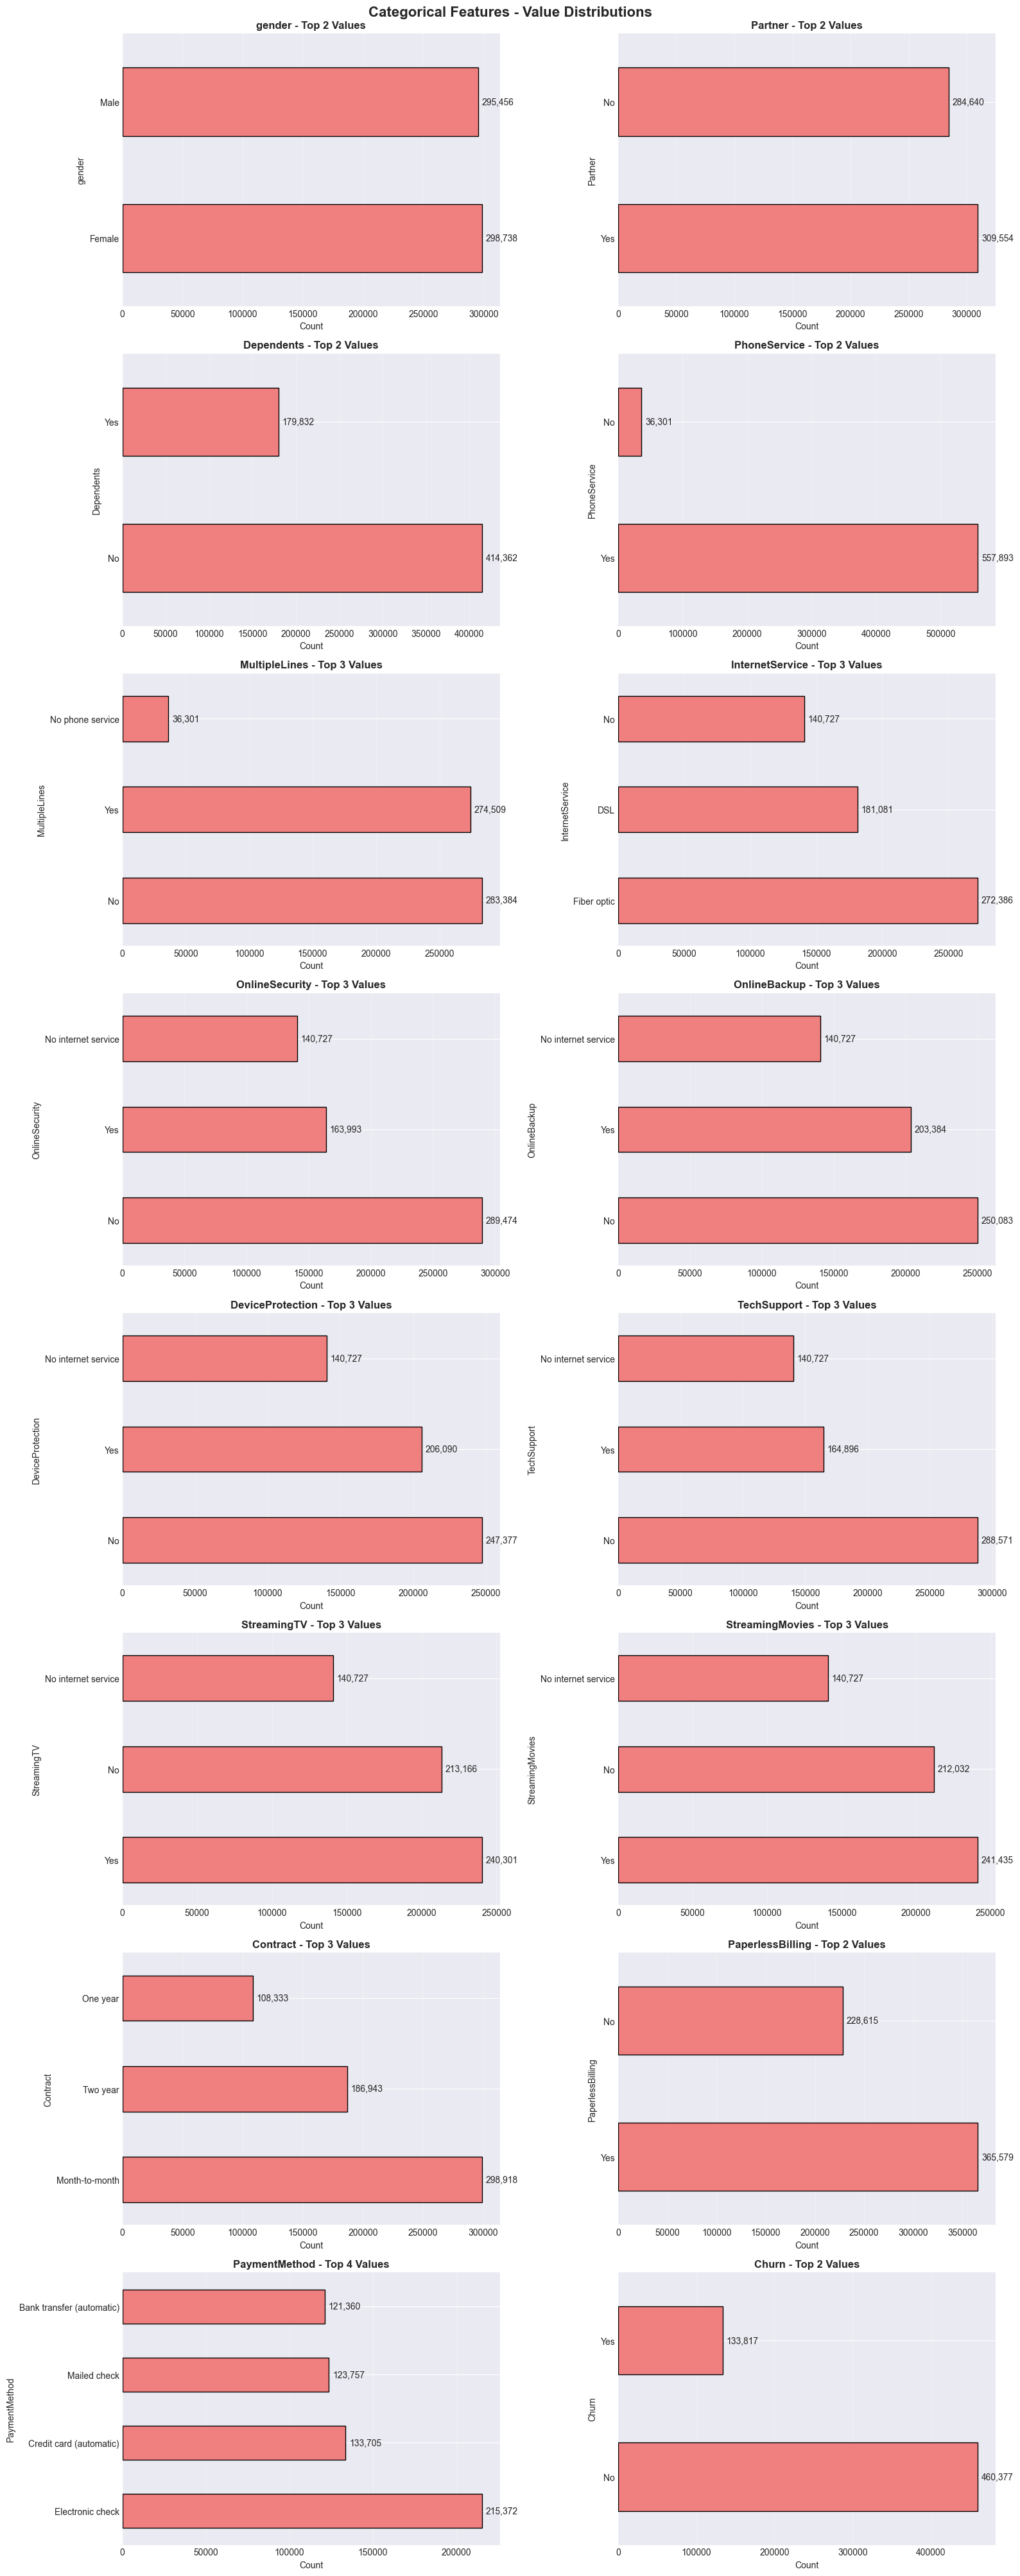

In [15]:
# Bar plots for categorical features
if len(categorical_cols) > 0:
    n_cols = 2
    n_rows = (len(categorical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes
    
    for idx, col in enumerate(categorical_cols):
        ax = axes[idx]
        value_counts = train_df[col].value_counts().head(15)
        value_counts.plot(kind='barh', ax=ax, color='lightcoral', edgecolor='black')
        ax.set_title(f'{col} - Top {len(value_counts)} Values', fontweight='bold')
        ax.set_xlabel('Count')
        ax.set_ylabel(col)
        ax.grid(axis='x', alpha=0.3)
        
        for i, v in enumerate(value_counts.values):
            ax.text(v + max(value_counts) * 0.01, i, f'{v:,}', va='center')
    
    for idx in range(len(categorical_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.suptitle('Categorical Features - Value Distributions', fontsize=16, fontweight='bold', y=1.002)
    plt.show()

# Target variable analysis

Data Type: object
Unique Values: 2

Value Distribution:


,Value,Count,Percentage
0,No,460377,77.479
1,Yes,133817,22.521


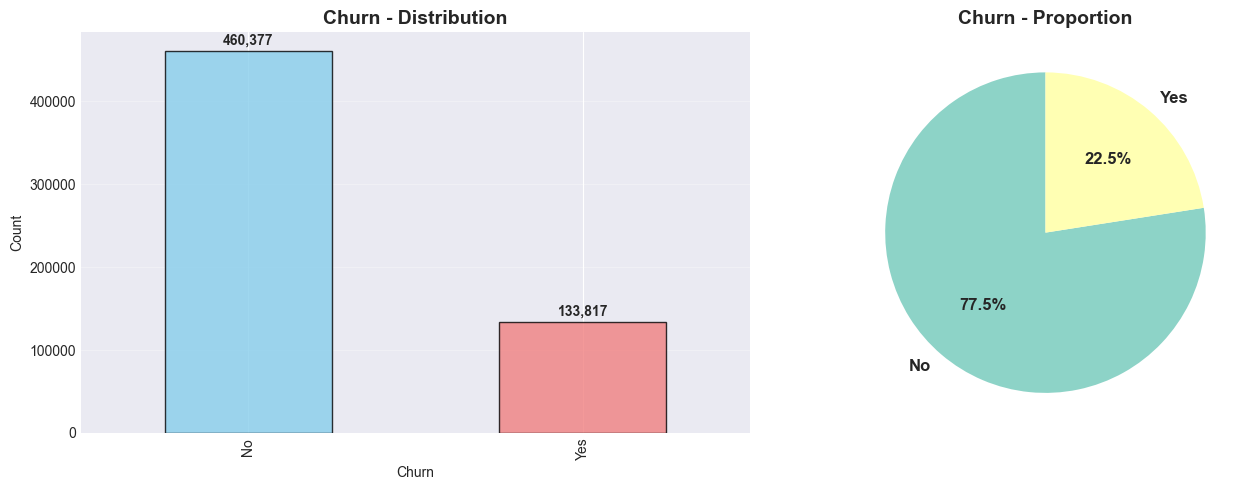


Class Balance Ratio: 0.291
   - SMOTE or other sampling techniques
   - Class weights in model training
   - Stratified cross-validation


In [16]:
if target_col in train_df.columns:
    target_counts = train_df[target_col].value_counts()
    print(f"Data Type: {train_df[target_col].dtype}")
    print(f"Unique Values: {train_df[target_col].nunique()}")
    print()
    print("Value Distribution:")
    display(pd.DataFrame({
        'Value': target_counts.index,
        'Count': target_counts.values,
        'Percentage': (target_counts / len(train_df) * 100).values
    }))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    target_counts.plot(kind='bar', ax=axes[0], color=['skyblue', 'lightcoral', 'lightgreen'][:len(target_counts)], 
                      edgecolor='black', alpha=0.8)
    axes[0].set_title(f'{target_col} - Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel(target_col)
    axes[0].set_ylabel('Count')
    axes[0].grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(target_counts.values):
        axes[0].text(i, v + max(target_counts) * 0.01, f'{v:,}', ha='center', va='bottom', fontweight='bold')
    
    colors = plt.cm.Set3(range(len(target_counts)))
    axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%', 
                startangle=90, colors=colors, textprops={'fontsize': 12, 'fontweight': 'bold'})
    axes[1].set_title(f'{target_col} - Proportion', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    if train_df[target_col].nunique() <= 10:
        balance_ratio = target_counts.min() / target_counts.max()
        print(f"\nClass Balance Ratio: {balance_ratio:.3f}")
        if balance_ratio < 0.5:
            print("  Warning: Dataset is imbalanced! Consider using:")
            print("   - SMOTE or other sampling techniques")
            print("   - Class weights in model training")
            print("   - Stratified cross-validation")
        else:
            print("Dataset is relatively balanced")
else:
    print(f"Target column '{target_col}' not found in training data")

# Correlation analysis

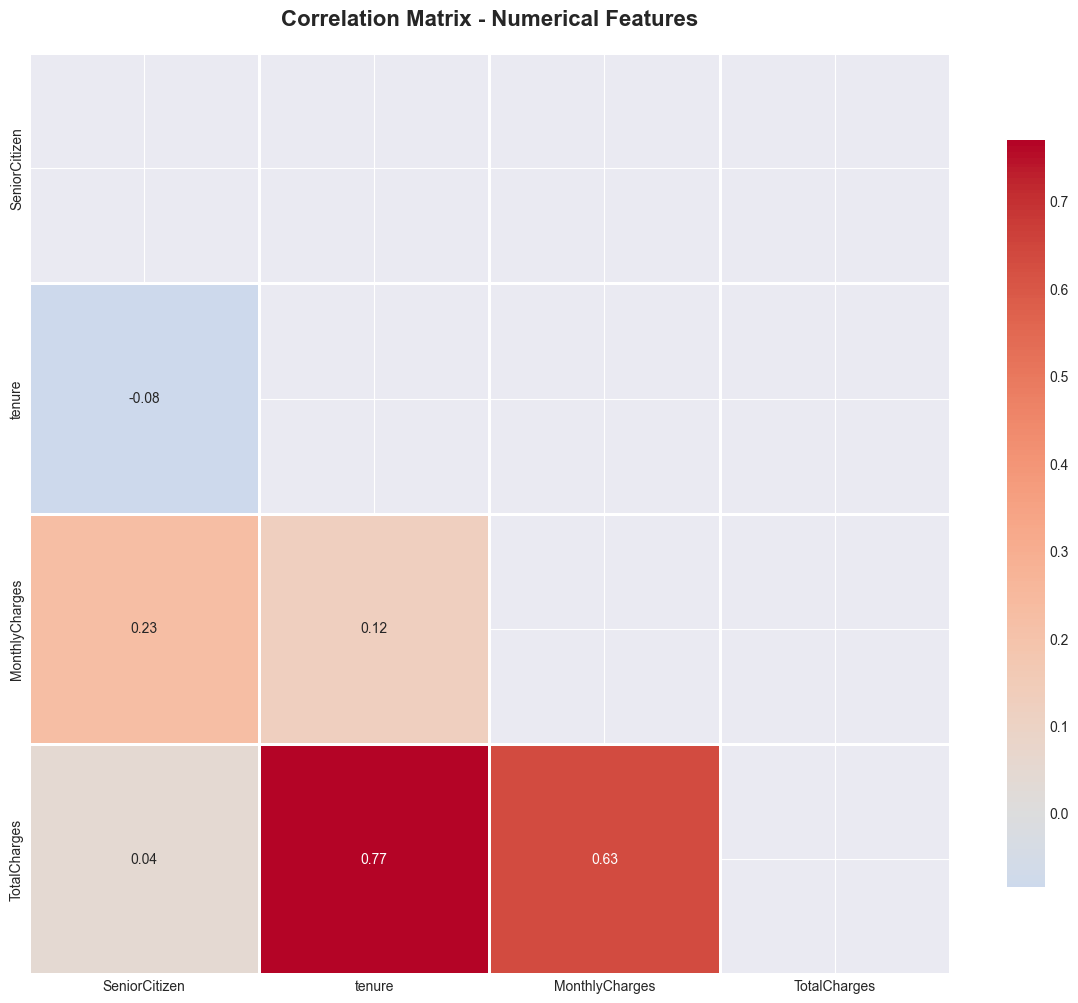

,Feature 1,Feature 2,Correlation
0,tenure,TotalCharges,0.770


In [17]:
# Correlation matrix for numerical features
if len(numerical_cols) > 0:
    # Include target if numerical
    corr_cols = numerical_cols.copy()
    if target_col in train_df.columns and train_df[target_col].dtype in ['int64', 'float64']:
        corr_cols.append(target_col)
    
    correlation_matrix = train_df[corr_cols].corr()
    
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix - Numerical Features', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # Highly correlated features
    high_corr = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.7:
                high_corr.append({
                    'Feature 1': correlation_matrix.columns[i],
                    'Feature 2': correlation_matrix.columns[j],
                    'Correlation': correlation_matrix.iloc[i, j]
                })
    
    if high_corr:
        display(pd.DataFrame(high_corr).sort_values('Correlation', key=abs, ascending=False))
    else:
        print("No highly correlated features found")

Target 'Churn' is categorical and encoded for correlation (unique=2)


,Feature,Correlation,Abs_Correlation
3,tenure,-0.418,0.418
0,MonthlyCharges,0.273,0.273
1,SeniorCitizen,0.236,0.236
2,TotalCharges,-0.218,0.218


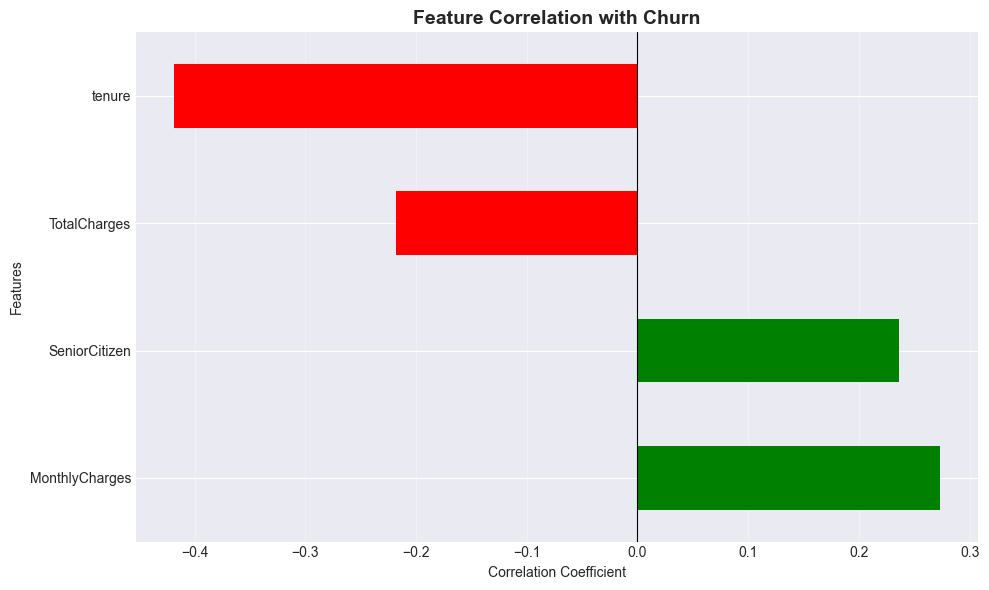

In [18]:
# Correlation with target variable
if target_col in train_df.columns and len(numerical_cols) > 0:
    target_series = train_df[target_col]

    # Convert non-numeric target to numeric codes for correlation analysis
    if not pd.api.types.is_numeric_dtype(target_series):
        unique_count = target_series.nunique(dropna=True)
        if unique_count <= 20:
            target_numeric = pd.factorize(target_series)[0]
            print(f"Target '{target_col}' is categorical and encoded for correlation (unique={unique_count})")
        else:
            target_numeric = None
            print(f"Target '{target_col}' has too many categories ({unique_count}); skipping target correlation")
    else:
        target_numeric = target_series

    if target_numeric is not None:
        corr_frame = train_df[numerical_cols].copy()
        corr_frame[target_col] = target_numeric
        target_corr = corr_frame.corr()[target_col].drop(target_col).sort_values(ascending=False)

        display(pd.DataFrame({
            'Feature': target_corr.index,
            'Correlation': target_corr.values,
            'Abs_Correlation': abs(target_corr.values)
        }).sort_values('Abs_Correlation', ascending=False))

        plt.figure(figsize=(10, 6))
        target_corr.plot(kind='barh', color=['green' if x > 0 else 'red' for x in target_corr.values])
        plt.title(f'Feature Correlation with {target_col}', fontsize=14, fontweight='bold')
        plt.xlabel('Correlation Coefficient')
        plt.ylabel('Features')
        plt.axvline(0, color='black', linewidth=0.8)
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print(f"Cannot compute target correlation. target_col='{target_col}', exists={target_col in train_df.columns}, numerical_cols={len(numerical_cols)}")

# Outlier detection

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,SeniorCitizen,0.000,0.000,0.000,0.000,0.000,67799,11.410
1,tenure,12.000,62.000,50.000,-63.000,137.000,0,0.000
2,MonthlyCharges,29.900,90.800,60.900,-61.450,182.150,0,0.000
3,TotalCharges,639.650,4263.800,3624.150,-4796.575,9700.025,0,0.000


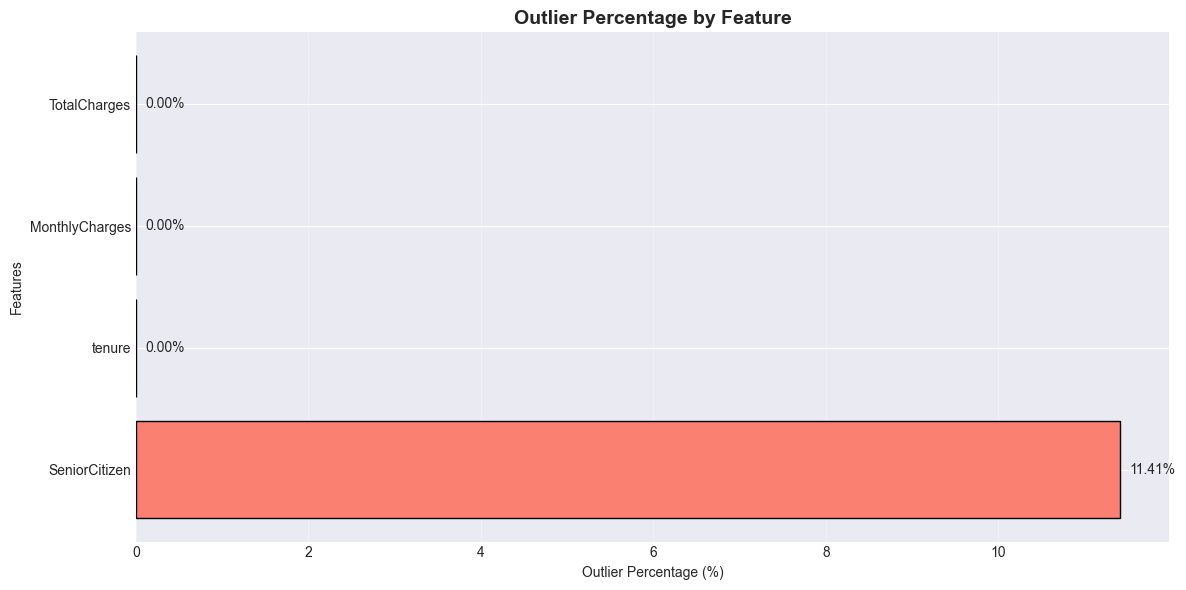

In [19]:
# Outlier detection using IQR method
if len(numerical_cols) > 0:
    outlier_summary = []
    
    for col in numerical_cols:
        Q1 = train_df[col].quantile(0.25)
        Q3 = train_df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = train_df[(train_df[col] < lower_bound) | (train_df[col] > upper_bound)]
        
        outlier_summary.append({
            'Feature': col,
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound,
            'Outlier_Count': len(outliers),
            'Outlier_Percentage': len(outliers) / len(train_df) * 100
        })
    
    outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier_Percentage', ascending=False)

    display(outlier_df)
    
    plt.figure(figsize=(12, 6))
    plt.barh(outlier_df['Feature'], outlier_df['Outlier_Percentage'], color='salmon', edgecolor='black')
    plt.xlabel('Outlier Percentage (%)')
    plt.ylabel('Features')
    plt.title('Outlier Percentage by Feature', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    
    for i, v in enumerate(outlier_df['Outlier_Percentage'].values):
        plt.text(v + max(outlier_df['Outlier_Percentage']) * 0.01, i, f'{v:.2f}%', va='center')
    
    plt.tight_layout()
    plt.show()

# Train vs Test comparison

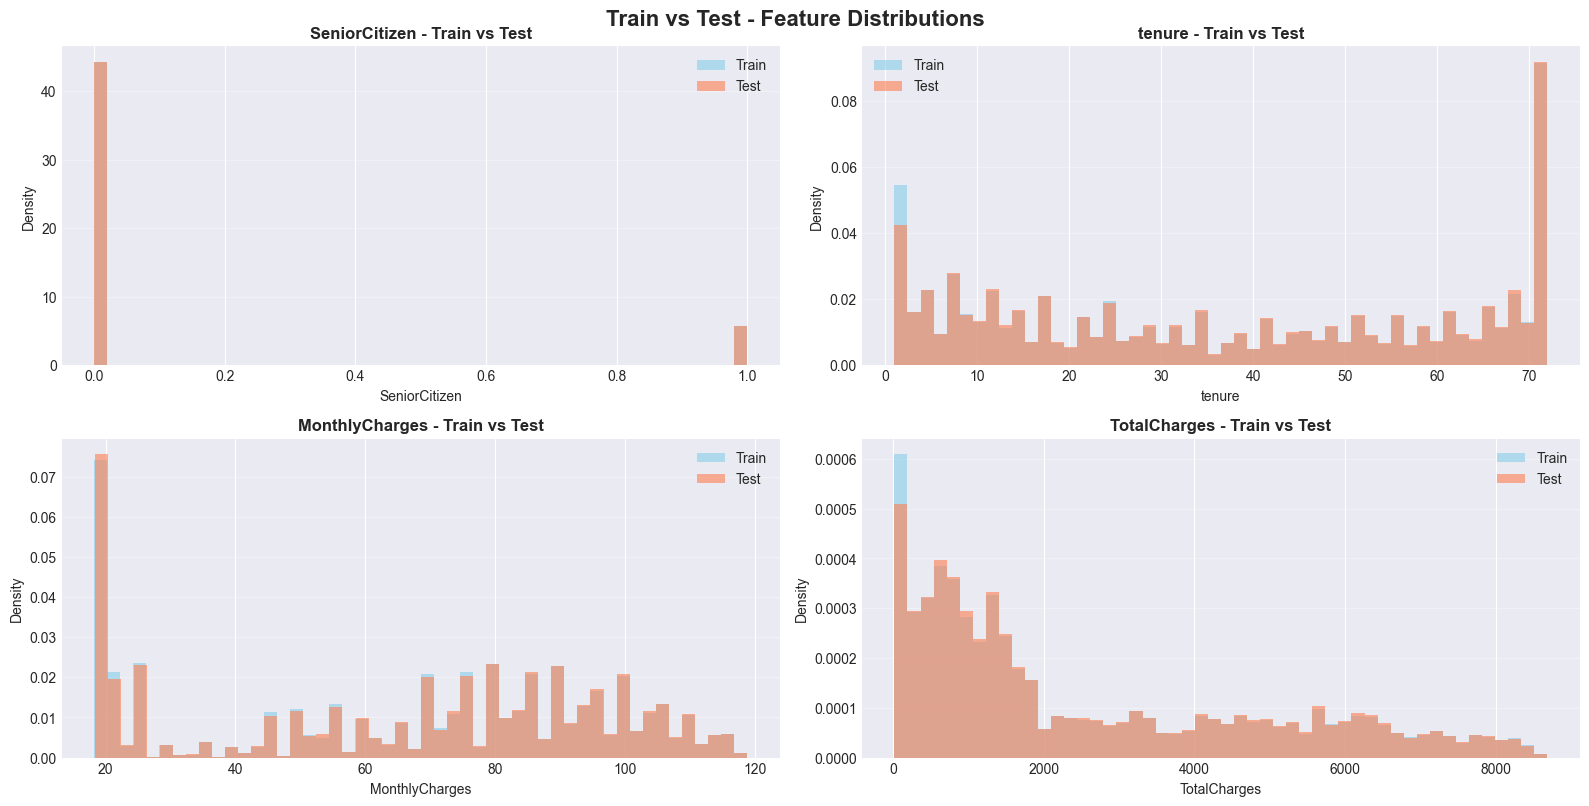

In [20]:
# Compare numerical features distributions
if len(numerical_cols) > 0:
    n_cols = 2
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes
    
    for idx, col in enumerate(numerical_cols):
        if col in test_df.columns:
            ax = axes[idx]
            
            train_df[col].hist(bins=50, ax=ax, color='skyblue', alpha=0.6, label='Train', density=True)
            test_df[col].hist(bins=50, ax=ax, color='coral', alpha=0.6, label='Test', density=True)
            
            ax.set_title(f'{col} - Train vs Test', fontweight='bold')
            ax.set_xlabel(col)
            ax.set_ylabel('Density')
            ax.legend()
            ax.grid(axis='y', alpha=0.3)
    
    for idx in range(len(numerical_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.suptitle('Train vs Test - Feature Distributions', fontsize=16, fontweight='bold', y=1.002)
    plt.show()

In [21]:
# Statistical comparison
if len(numerical_cols) > 0:
    comparison = []
    
    for col in numerical_cols:
        if col in test_df.columns:
            comparison.append({
                'Feature': col,
                'Train_Mean': train_df[col].mean(),
                'Test_Mean': test_df[col].mean(),
                'Mean_Diff_%': ((test_df[col].mean() - train_df[col].mean()) / train_df[col].mean() * 100) if train_df[col].mean() != 0 else 0,
                'Train_Std': train_df[col].std(),
                'Test_Std': test_df[col].std()
            })
    
    comparison_df = pd.DataFrame(comparison)
    
    display(comparison_df.style.background_gradient(cmap='RdYlGn_r', subset=['Mean_Diff_%']))
    
    print("\nFeatures with >10% mean difference:")
    large_diff = comparison_df[abs(comparison_df['Mean_Diff_%']) > 10]
    if len(large_diff) > 0:
        display(large_diff[['Feature', 'Mean_Diff_%']])
    else:
        print("No significant differences found")

,Feature,Train_Mean,Test_Mean,Mean_Diff_%,Train_Std,Test_Std
0,SeniorCitizen,0.114102,0.113620,-0.422494,0.317936,0.317350
1,tenure,36.577258,37.279716,1.920478,25.061922,24.777625
2,MonthlyCharges,65.866223,66.130803,0.401693,31.067444,31.104139
3,TotalCharges,2494.377057,2544.617351,2.014142,2353.916710,2348.124379



Features with >10% mean difference:
No significant differences found
